# Day 19

---


In [1]:
import grama as gr
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
DF = gr.Intention()

# Set figure options
plt.rcParams['figure.figsize'] = [6, 6] # Need square aspect ratio for gradients to appear normal
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower


## Exploratory Data Analysis



In [2]:
from grama.data import df_shewhart
df_shewhart.head()

,specimen,tensile_strength,hardness,density
0,1,29314,53.0,2.666
1,2,34860,70.2,2.708
2,3,36818,84.3,2.865
3,4,30120,55.3,2.627
4,5,34020,78.5,2.581


### 1d plots

Tips:

- Switch between plotting the three different variables
- Vary the number of bins for each variable
- Note what you see in the plots


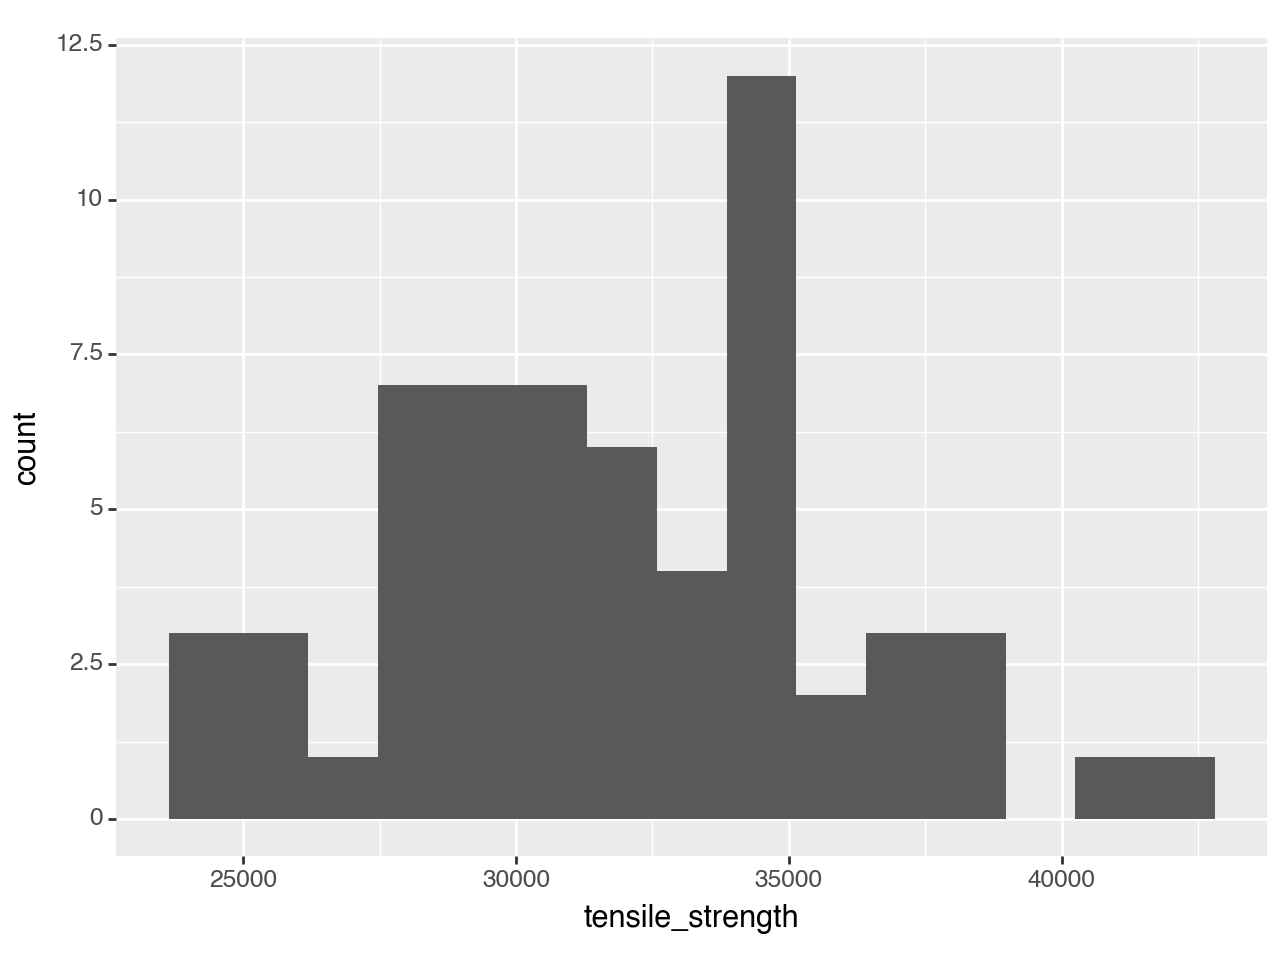

<Figure Size: (640 x 480)>

In [3]:
(
    df_shewhart
    >> gr.ggplot(gr.aes("tensile_strength"))
    # >> gr.ggplot(gr.aes("hardness"))
    # >> gr.ggplot(gr.aes("density"))
    + gr.geom_histogram(bins=15)
)

*Observations*

- (Take your notes here)

### 2d plots

Tips:

- Switch between plotting the different pairs of variables
- Note what you see in the plots

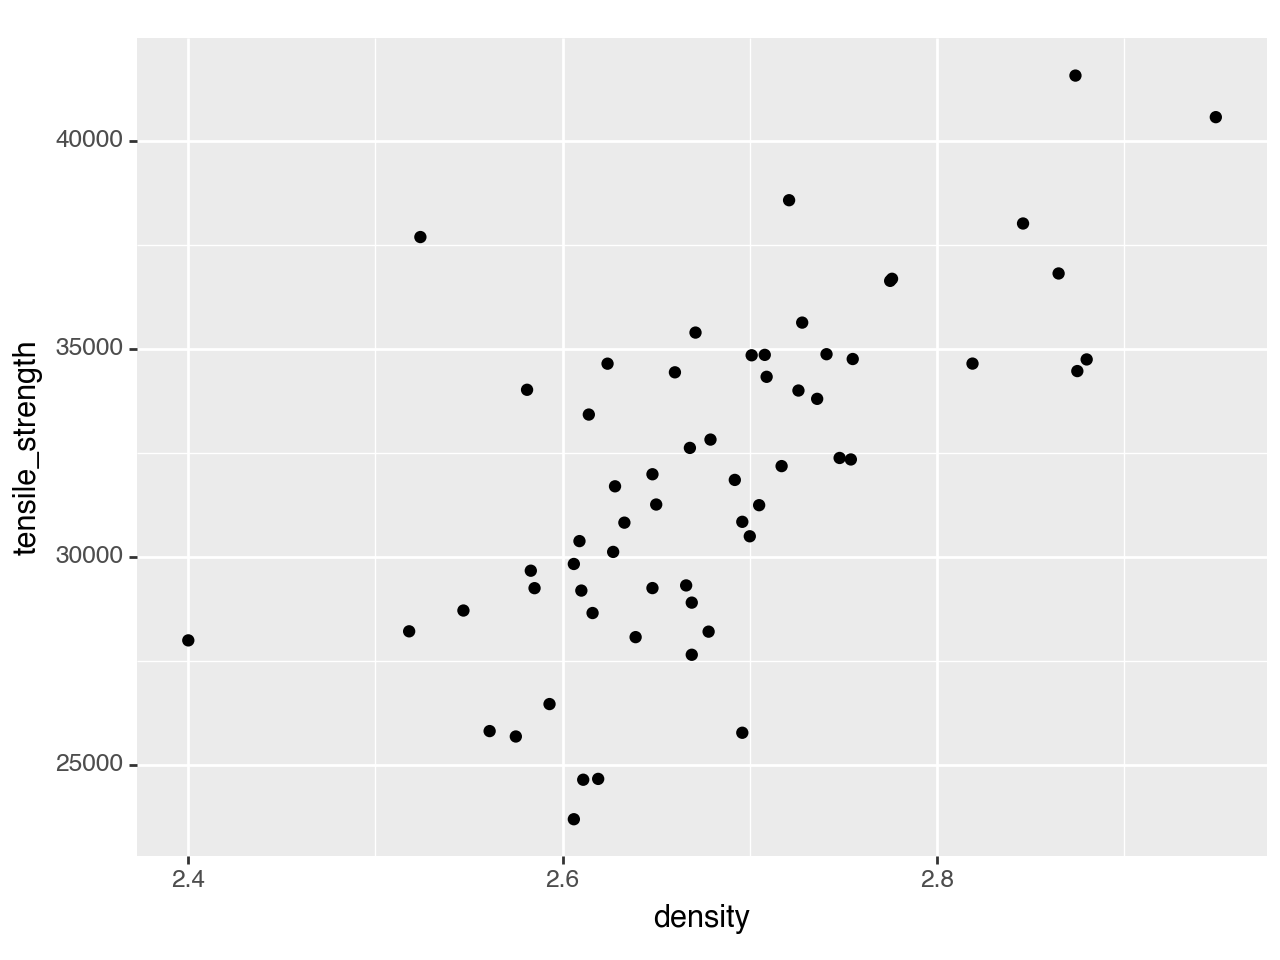

<Figure Size: (640 x 480)>

In [4]:
(
    df_shewhart
    >> gr.ggplot(gr.aes("density", "tensile_strength"))
    # >> gr.ggplot(gr.aes("density", "hardness"))
    # >> gr.ggplot(gr.aes("tensile_strength", "hardness"))
    + gr.geom_point()
)

*Observations*

- (Take your notes here)

## Modeling

### Choose distributions

Look at AMAU Appendix D (Readings folder on Canvas) for more details on distributions you can use for modeling.

> A pox on you if you choose a normal distribution for *every* variable....

In [5]:
# Change the distribution shape for each variable
dist_density = "uniform"
dist_strength = "uniform"
dist_hardness = "uniform"

md_shewhart = (
    gr.Model("Material Variability Model")
    >> gr.cp_marginals(
        density=gr.marg_fit(dist_density, df_shewhart.density),
        tensile_strength=gr.marg_fit(dist_strength, df_shewhart.tensile_strength),
        hardness=gr.marg_fit(dist_hardness, df_shewhart.hardness),
    )
    >> gr.cp_copula_independence()
)
md_shewhart 

model: Material Variability Model

  inputs:
    var_det:

    var_rand:
      density: (+0) uniform, {'mean': '2.670e+00', 's.d.': '1.600e-01', 'COV': 0.06, 'skew.': 0.0, 'kurt.': 1.8}
      tensile_strength: (+0) uniform, {'mean': '3.263e+04', 's.d.': '5.164e+03', 'COV': 0.16, 'skew.': 0.0, 'kurt.': 1.8}
      hardness: (+0) uniform, {'mean': '7.240e+01', 's.d.': '1.328e+01', 'COV': 0.18, 'skew.': 0.0, 'kurt.': 1.8}

    copula:
      Independence copula

  functions:

### Assess model: 1d

Use the following code to help assess your choice of distribution for each variable.

Estimated runtime: 0.0000 sec


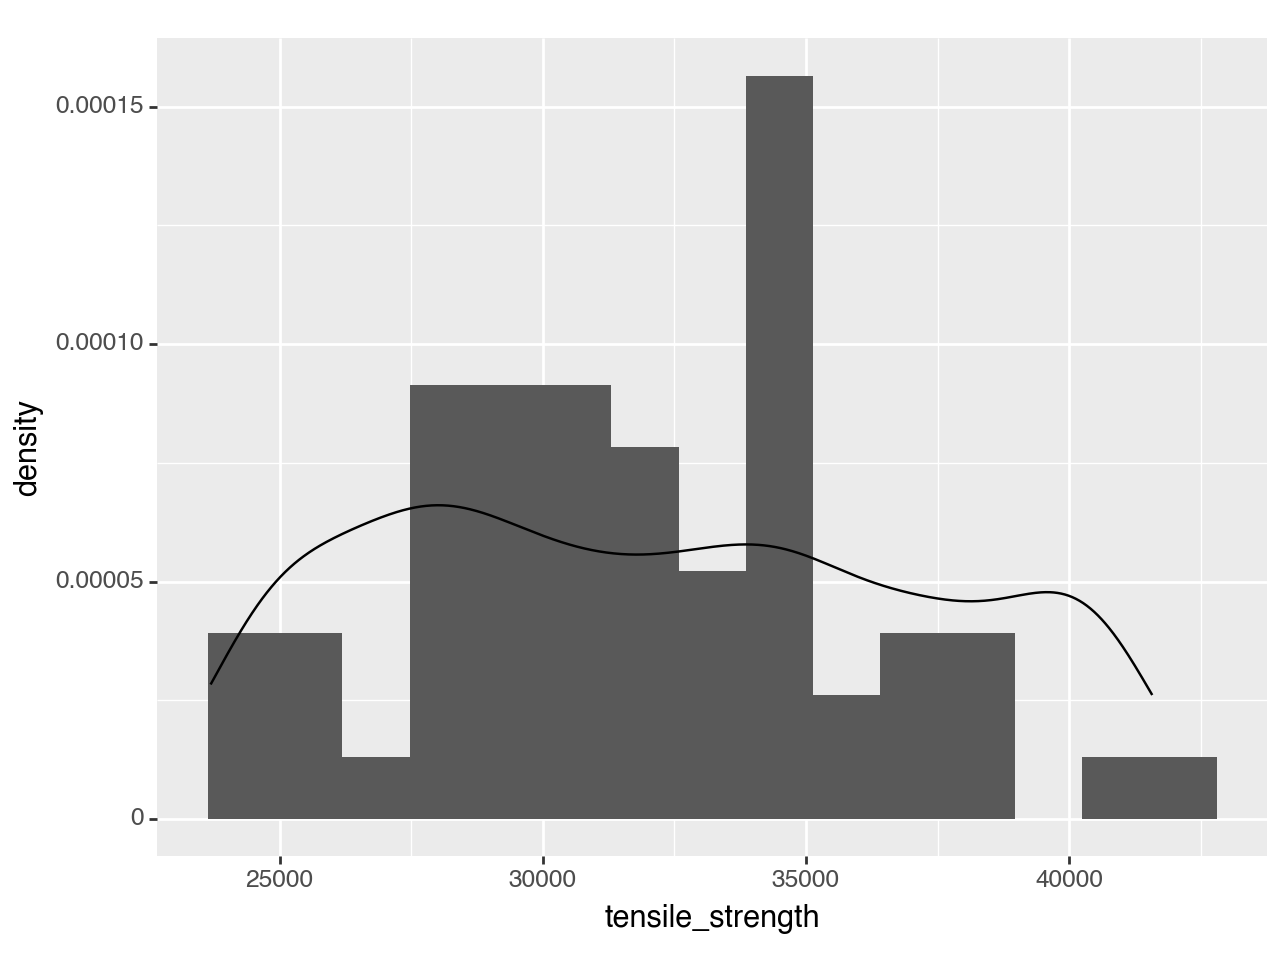

<Figure Size: (640 x 480)>

In [6]:
(
    df_shewhart
    >> gr.ggplot(gr.aes("tensile_strength"))
    # >> gr.ggplot(gr.aes("hardness"))
    # >> gr.ggplot(gr.aes("density"))
    + gr.geom_histogram(
        mapping=gr.aes(y=gr.after_stat("density")),
        bins=15,
    )
    + gr.geom_density(
        data=md_shewhart
        >> gr.ev_sample(df_det="nom", skip=True, n=1000),
    )
)

### Assess model: 2d

Use the following to assess your model

Estimated runtime: 0.0000 sec


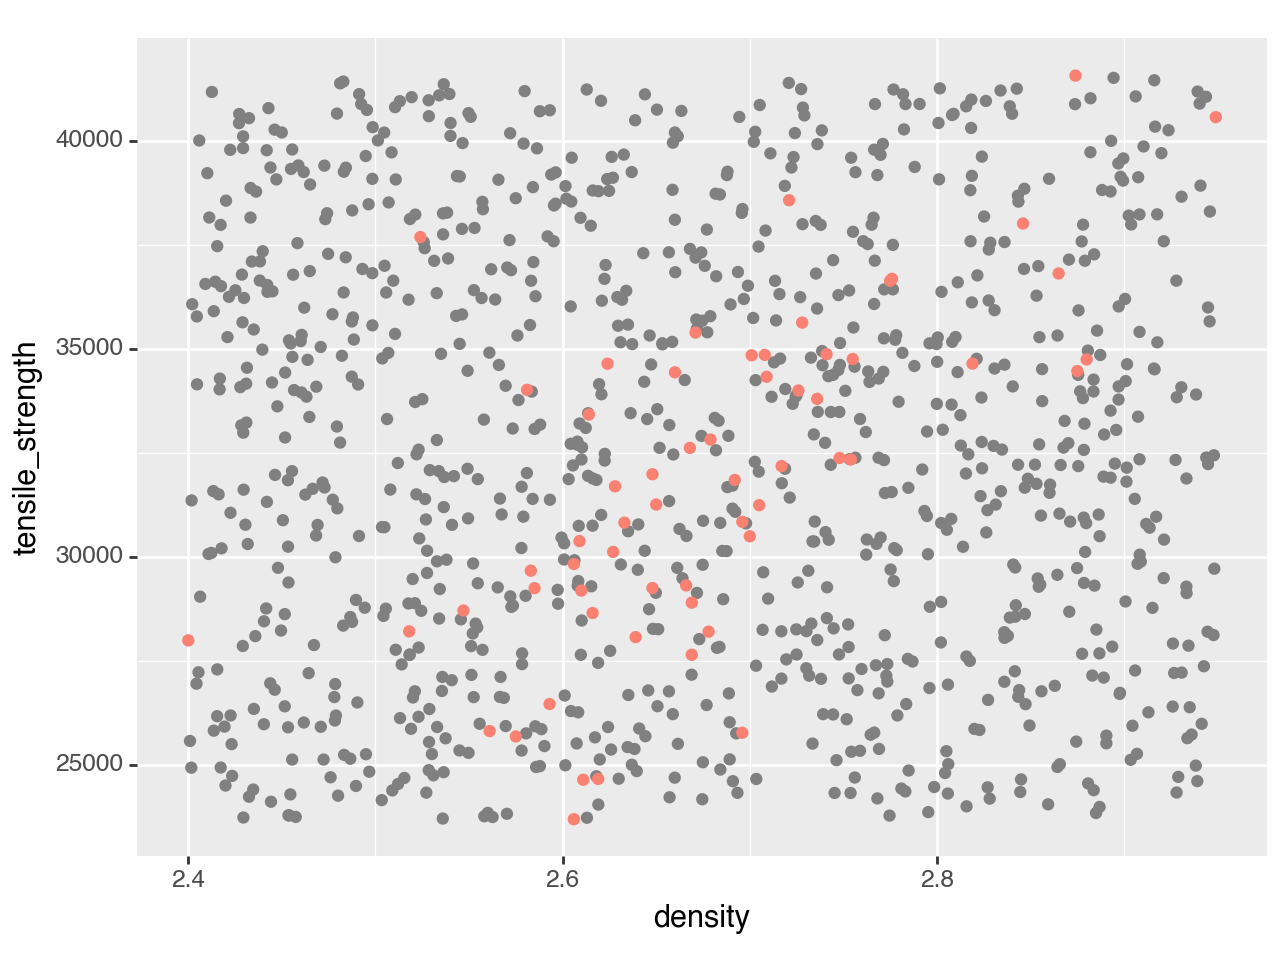

<Figure Size: (640 x 480)>

In [7]:
(
    df_shewhart
    >> gr.ggplot(gr.aes("density", "tensile_strength"))
    # >> gr.ggplot(gr.aes("density", "hardness"))
    # >> gr.ggplot(gr.aes("tensile_strength", "hardness"))

    + gr.geom_point(
        data=md_shewhart
        >> gr.ev_sample(df_det="nom", skip=True, n=1000),
        color="grey"
    )
    + gr.geom_point(color="salmon")
)